In [39]:
import os, sys, re, random, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torchvision
from pathlib import Path
from PIL import Image

In [19]:
print("python     :", sys.version.split()[0])
print("torch      :", torch.__version__)
print("torchvision:", torchvision.__version__)
print("cuda       :", torch.cuda.is_available())

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print("seed set")

python     : 3.12.4
torch      : 2.11.0+cpu
torchvision: 0.26.0+cpu
cuda       : False
seed set


In [13]:
ROOT = Path("../data/raw")
CSV_PATH = ROOT / "selected_by_name_iimk_subset_public.csv"
IMG_DIR  = ROOT / "dataset"

df = pd.read_csv(CSV_PATH)
print(f"CSV rows   : {len(df)}")
print(f"CSV columns: {df.columns.tolist()}")

img_files = sorted(IMG_DIR.glob("*.jpg"))
print(f"Image files: {len(img_files)}")

CSV rows   : 1389
CSV columns: ['Unnamed: 0', 'code', 'name', 'description', 'material', 'size', 'fragm', 'cultlayer', 'execorg', 'survyear']
Image files: 1388


In [14]:
import unicodedata

def normalize(s):
    return unicodedata.normalize("NFC", str(s))

files_by_code = {}
for f in img_files:
    code = normalize(f.stem.replace("_orig", ""))
    files_by_code.setdefault(code, []).append(f)

df["image_path"] = df["code"].map(lambda c: files_by_code.get(normalize(c), []))
df["n_images"]   = df["image_path"].apply(len)

print(f"rows с >=1 картинкой : {(df['n_images'] >= 1).sum()} / {len(df)}")
print(f"rows без картинок    : {(df['n_images'] == 0).sum()}")
print(f"всего файлов сматчено: {df['n_images'].sum()}")
print()
print("Распределение числа картинок на запись:")
print(df["n_images"].value_counts().sort_index())

rows с >=1 картинкой : 1389 / 1389
rows без картинок    : 0
всего файлов сматчено: 1389

Распределение числа картинок на запись:
n_images
1    1389
Name: count, dtype: int64


In [15]:
rows = []
for _, r in df.iterrows():
    for img_path in r["image_path"]:
        rows.append({
            "code": r["code"],
            "name": r["name"],
            "description": r["description"],
            "material": r["material"],
            "size": r["size"],
            "fragm": r["fragm"],
            "cultlayer": r["cultlayer"],
            "image_file": str(img_path.relative_to(ROOT)),
            "group_key": normalize(str(r["code"])),
        })

df_long = pd.DataFrame(rows)
print(f"Пар (строка ↔ файл): {len(df_long)}")
print(f"Уникальных group_key: {df_long['group_key'].nunique()}")
print()
print("Колонки:", df_long.columns.tolist())
df_long.head()

Пар (строка ↔ файл): 1389
Уникальных group_key: 1388

Колонки: ['code', 'name', 'description', 'material', 'size', 'fragm', 'cultlayer', 'image_file', 'group_key']


,code,name,description,material,size,fragm,cultlayer,image_file,group_key
0,М102-2012-1-0494,Изразец,Изразца красноглиняного с белой поливой и коба...,Керамика,"7+ х 3,5+ х 1,1+ см",Фрагмент,Пестрая мешаная супесь,dataset\М102-2012-1-0494_orig.jpg,М102-2012-1-0494
1,М102-2012-1-0496,Изразец,Изразца красноглиняного плоского с белой полив...,Керамика,"9,9+ х 6,4+ х 1,3+ см",Фрагмент,Пестрая мешаная супесь,dataset\М102-2012-1-0496_orig.jpg,М102-2012-1-0496
2,М102-2012-1-0529,Изразец,Изразца-перемычки красноглиняного с белой поли...,Керамика,"4,5+ х 4,3 х 4,2+ см",Фрагмент,Пестрая мешаная супесь,dataset\М102-2012-1-0529_orig.jpg,М102-2012-1-0529
3,М102-2012-1-0585,Тарелка,Сосуда (тарелки ?) фаянсового с белой поливой ...,Фаянс,D? см,Фрагмент,Дерн со щепой,dataset\М102-2012-1-0585_orig.jpg,М102-2012-1-0585
4,М102-2012-1-0603,Изразец,Изразца (перемычки?) красноглиняного с белой п...,Керамика,"3,8+ х 2,8 х 5,1+ см",Фрагмент,Дерн со щепой,dataset\М102-2012-1-0603_orig.jpg,М102-2012-1-0603


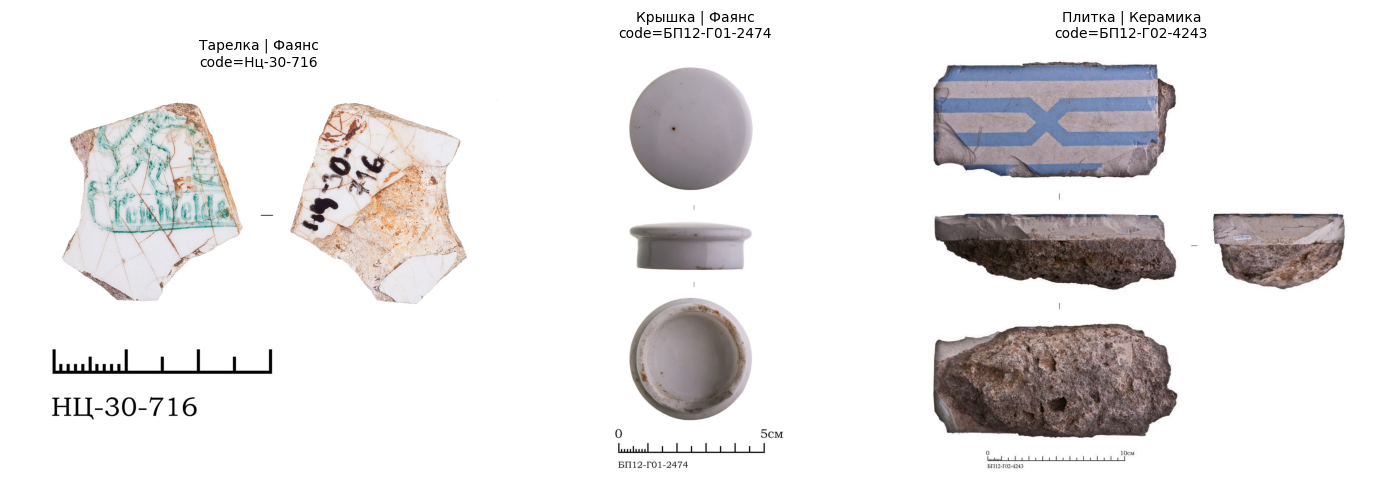

code     : Нц-30-716
name     : Тарелка
material : Фаянс
fragm    : Фрагмент
desc     : Тарелки фаянсовой с клеймом донца фр-т
file     : dataset\Нц-30-716_orig.jpg
------------------------------------------------------------
code     : БП12-Г01-2474
name     : Крышка
material : Фаянс
fragm    : Фрагмент
desc     : Сосуда фаянсового крышка фрагментированная
file     : dataset\БП12-Г01-2474_orig.jpg
------------------------------------------------------------
code     : БП12-Г02-4243
name     : Плитка
material : Керамика
fragm    : Фрагмент
desc     : Плитка напольная керамическая метлахская с голубой росписью и следами раствора фрагментированная
file     : dataset\БП12-Г02-4243_orig.jpg
------------------------------------------------------------


In [21]:
sample = df_long.sample(3, random_state=SEED).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (_, r) in zip(axes, sample.iterrows()):
    img = Image.open(ROOT / r["image_file"])
    ax.imshow(img); ax.axis("off")
    ax.set_title(f"{r['name']} | {r['material']}\ncode={r['code']}", fontsize=10)
plt.tight_layout(); plt.show()

for _, r in sample.iterrows():
    print(f"code     : {r['code']}")
    print(f"name     : {r['name']}")
    print(f"material : {r['material']}")
    print(f"fragm    : {r['fragm']}")
    print(f"desc     : {r['description']}")
    print(f"file     : {r['image_file']}")
    print("-" * 60)

In [10]:
INTERIM = Path("../data/interim")
INTERIM.mkdir(parents=True, exist_ok=True)
out_path = INTERIM / "items_with_images.csv"
df_long.to_csv(out_path, index=False)
print(f"Saved: {out_path}  ({len(df_long)} rows)")

Saved: ..\data\interim\items_with_images.csv  (1389 rows)


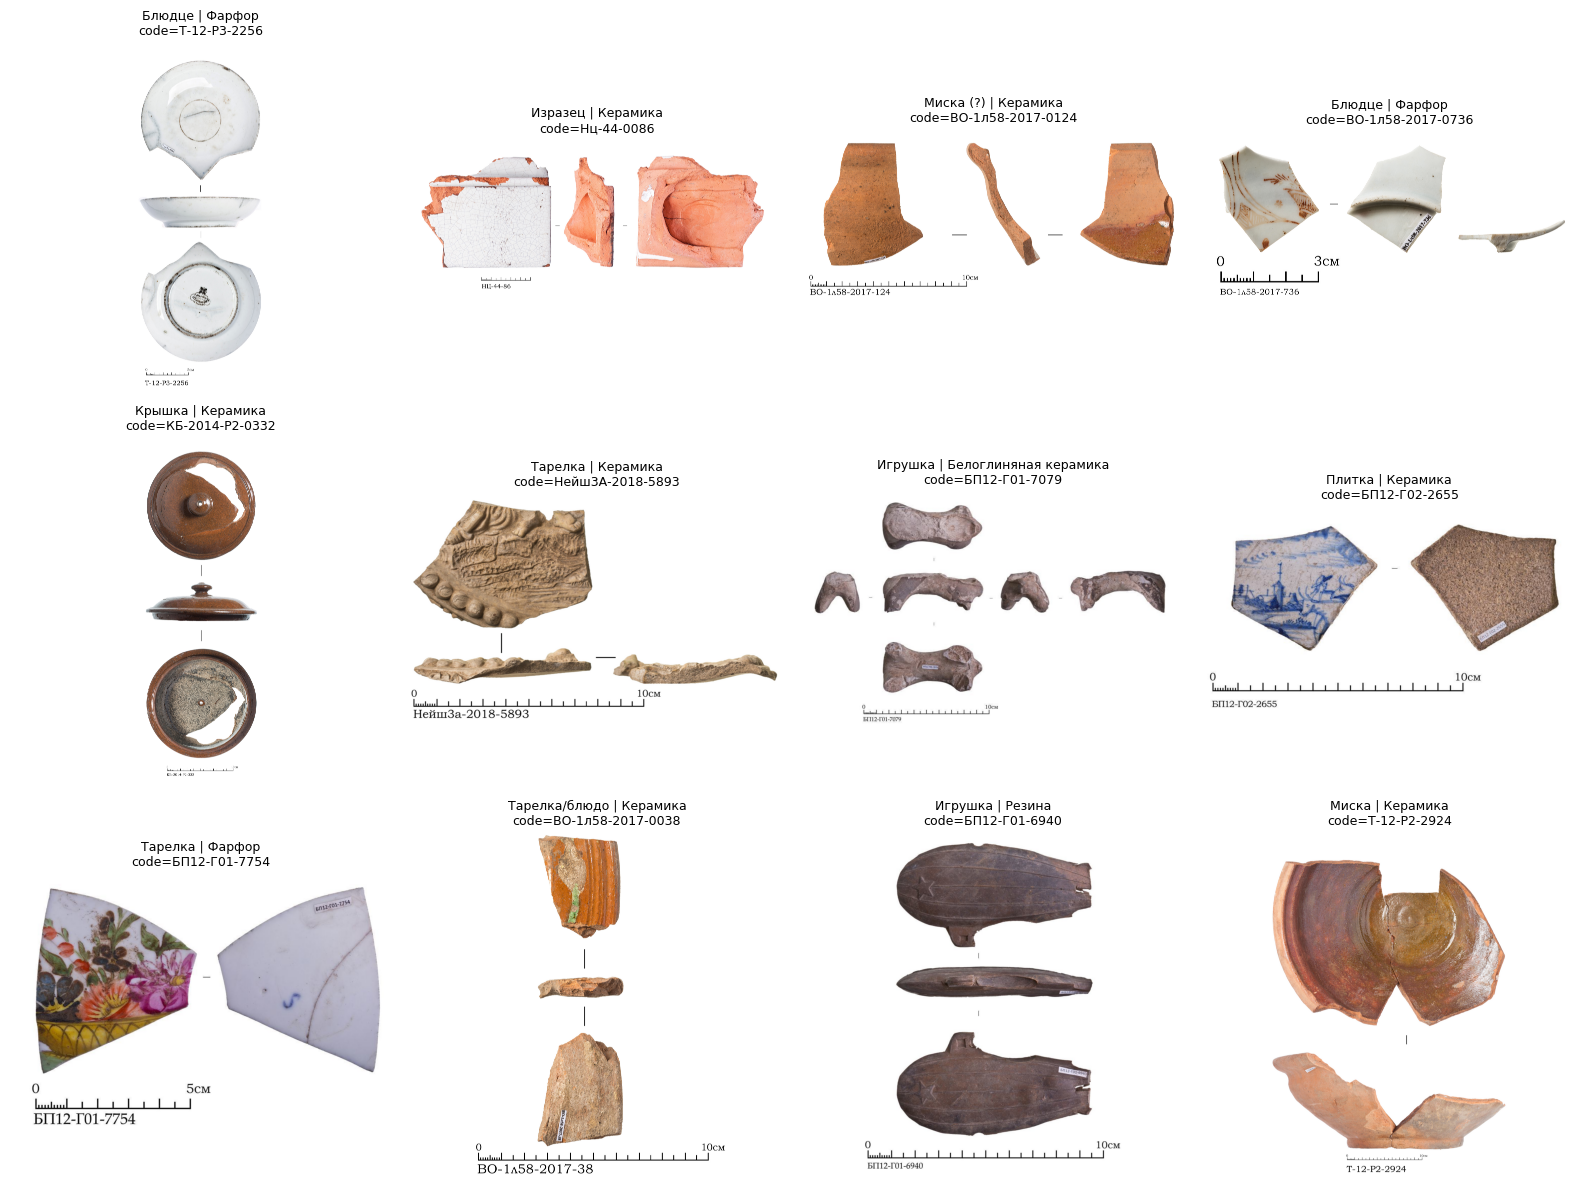

Saved: artifacts/figures/eda_grid_12.png  (12 images)


In [23]:
N = 12
parts = []
for name, sub in df_long.groupby("name"):
    parts.append(sub.sample(min(2, len(sub)), random_state=SEED))
samples = (
    pd.concat(parts)
      .sample(frac=1, random_state=SEED) 
      .head(N)
      .reset_index(drop=True)
)

cols = 4
rows = math.ceil(N / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

for ax, (_, r) in zip(axes, samples.iterrows()):
    img = Image.open(ROOT / r["image_file"])
    ax.imshow(img)
    ax.axis("off")
    title = f"{r['name']} | {r['material']}\ncode={r['code']}"
    ax.set_title(title, fontsize=9)

for ax in axes[len(samples):]:
    ax.axis("off")

plt.tight_layout()
Path("../artifacts/figures").mkdir(parents=True, exist_ok=True)
plt.savefig("../artifacts/figures/eda_grid_12.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: artifacts/figures/eda_grid_12.png  ({len(samples)} images)")

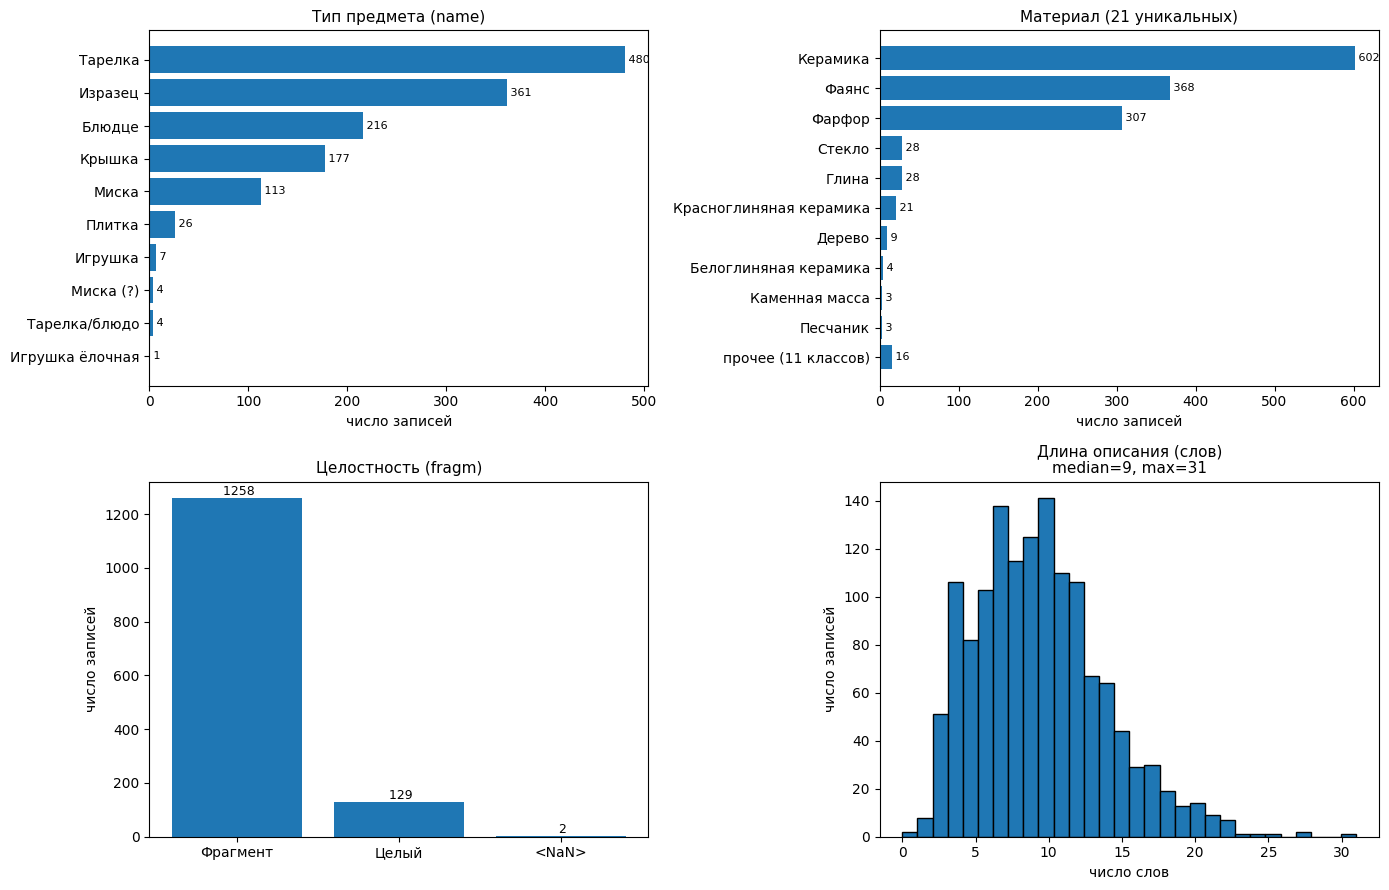

Saved: artifacts/figures/eda_field_distributions.png


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

name_counts = df_long["name"].value_counts()
axes[0,0].barh(name_counts.index[::-1], name_counts.values[::-1])
axes[0,0].set_title("Тип предмета (name)", fontsize=11)
axes[0,0].set_xlabel("число записей")
for i, v in enumerate(name_counts.values[::-1]):
    axes[0,0].text(v, i, f" {v}", va="center", fontsize=8)

mat_counts = df_long["material"].value_counts()
top = mat_counts.head(10)
other = mat_counts.iloc[10:].sum()
mat_plot = pd.concat([top, pd.Series({f"прочее ({len(mat_counts)-10} классов)": other})])
axes[0,1].barh(mat_plot.index[::-1], mat_plot.values[::-1])
axes[0,1].set_title(f"Материал ({len(mat_counts)} уникальных)", fontsize=11)
axes[0,1].set_xlabel("число записей")
for i, v in enumerate(mat_plot.values[::-1]):
    axes[0,1].text(v, i, f" {v}", va="center", fontsize=8)

fragm_counts = df_long["fragm"].fillna("<NaN>").value_counts()
axes[1,0].bar(fragm_counts.index, fragm_counts.values)
axes[1,0].set_title("Целостность (fragm)", fontsize=11)
axes[1,0].set_ylabel("число записей")
for i, v in enumerate(fragm_counts.values):
    axes[1,0].text(i, v, f" {v}", ha="center", va="bottom", fontsize=9)

desc_words = df_long["description"].fillna("").str.split().str.len()
axes[1,1].hist(desc_words, bins=30, edgecolor="black")
axes[1,1].set_title(f"Длина описания (слов)\nmedian={desc_words.median():.0f}, max={desc_words.max()}", fontsize=11)
axes[1,1].set_xlabel("число слов")
axes[1,1].set_ylabel("число записей")

plt.tight_layout()
plt.savefig("../artifacts/figures/eda_field_distributions.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: artifacts/figures/eda_field_distributions.png")

reading sizes:   0%|          | 0/1388 [00:00<?, ?it/s]

Размеры (px):
             w        h  longest  megapixels
count   1388.0   1388.0   1388.0      1388.0
mean    5199.7   4279.2   5956.6        25.1
std     2937.5   2456.8   2982.4        22.3
min      543.0    218.0   1080.0         0.2
25%     3168.0   2552.5   3768.2         9.4
50%     4671.0   3654.5   5760.0        19.8
75%     6910.0   5500.8   7930.5        34.9
max    18808.0  14212.0  18808.0       184.0

Aspect ratio (W/H):
count    1388.00
mean        1.41
std         0.77
min         0.26
25%         0.77
50%         1.32
75%         1.90
max         4.95
Name: aspect, dtype: float64


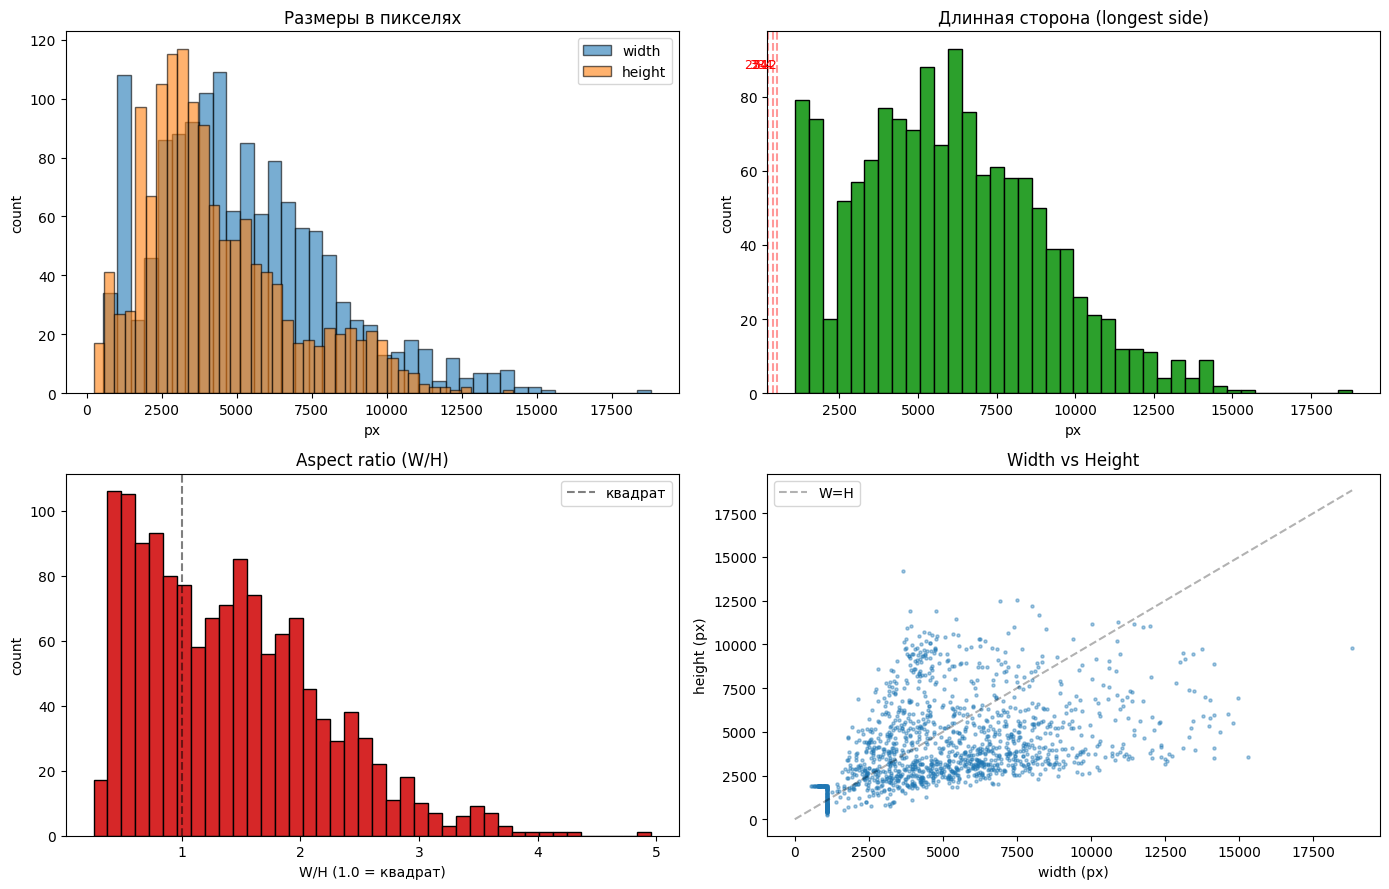

Saved: artifacts/figures/eda_image_sizes.png
Saved: data/interim/image_sizes.csv


In [27]:
from tqdm.auto import tqdm
import warnings

Image.MAX_IMAGE_PIXELS = None
warnings.simplefilter("ignore", Image.DecompressionBombWarning)

sizes = []
for img_path in tqdm(img_files, desc="reading sizes"):
    with Image.open(img_path) as im:
        w, h = im.size
    sizes.append({"file": img_path.name, "w": w, "h": h})
size_df = pd.DataFrame(sizes)
size_df["aspect"]    = size_df["w"] / size_df["h"]
size_df["longest"]   = size_df[["w", "h"]].max(axis=1)
size_df["megapixels"] = size_df["w"] * size_df["h"] / 1e6

print("Размеры (px):")
print(size_df[["w", "h", "longest", "megapixels"]].describe().round(1))
print(f"\nAspect ratio (W/H):")
print(size_df["aspect"].describe().round(2))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 3.1 — distribution: ширина и высота
axes[0,0].hist(size_df["w"], bins=40, alpha=0.6, label="width",  edgecolor="black")
axes[0,0].hist(size_df["h"], bins=40, alpha=0.6, label="height", edgecolor="black")
axes[0,0].set_title("Размеры в пикселях")
axes[0,0].set_xlabel("px"); axes[0,0].set_ylabel("count")
axes[0,0].legend()

# 3.2 — distribution: longest side
axes[0,1].hist(size_df["longest"], bins=40, edgecolor="black", color="C2")
axes[0,1].set_title("Длинная сторона (longest side)")
axes[0,1].set_xlabel("px"); axes[0,1].set_ylabel("count")
for thresh, label in [(224, "224"), (384, "384"), (512, "512")]:
    axes[0,1].axvline(thresh, color="red", linestyle="--", alpha=0.4)
    axes[0,1].text(thresh, axes[0,1].get_ylim()[1]*0.9, label, color="red", fontsize=9, ha="right")

# 3.3 — distribution: aspect ratio (log scale, чтобы видеть и "квадратные", и "тонкие")
axes[1,0].hist(size_df["aspect"], bins=40, edgecolor="black", color="C3")
axes[1,0].set_title("Aspect ratio (W/H)")
axes[1,0].set_xlabel("W/H (1.0 = квадрат)")
axes[1,0].set_ylabel("count")
axes[1,0].axvline(1.0, color="black", linestyle="--", alpha=0.5, label="квадрат")
axes[1,0].legend()

# 3.4 — scatter: H vs W
axes[1,1].scatter(size_df["w"], size_df["h"], s=5, alpha=0.4)
axes[1,1].set_title("Width vs Height")
axes[1,1].set_xlabel("width (px)"); axes[1,1].set_ylabel("height (px)")
axes[1,1].plot([0, size_df["w"].max()], [0, size_df["w"].max()], "k--", alpha=0.3, label="W=H")
axes[1,1].legend()

plt.tight_layout()
plt.savefig("../artifacts/figures/eda_image_sizes.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: artifacts/figures/eda_image_sizes.png")
size_df.to_csv("../data/interim/image_sizes.csv", index=False)
print("Saved: data/interim/image_sizes.csv")

quick stats:   0%|          | 0/60 [00:00<?, ?it/s]

Распределение fg_ratio:
count    60.000
mean      0.337
std       0.131
min       0.090
25%       0.271
50%       0.317
75%       0.392
max       0.994
Name: fg_ratio, dtype: float64

bg_type:
bg_type
white         53
light_gray     4
other          3
Name: count, dtype: int64


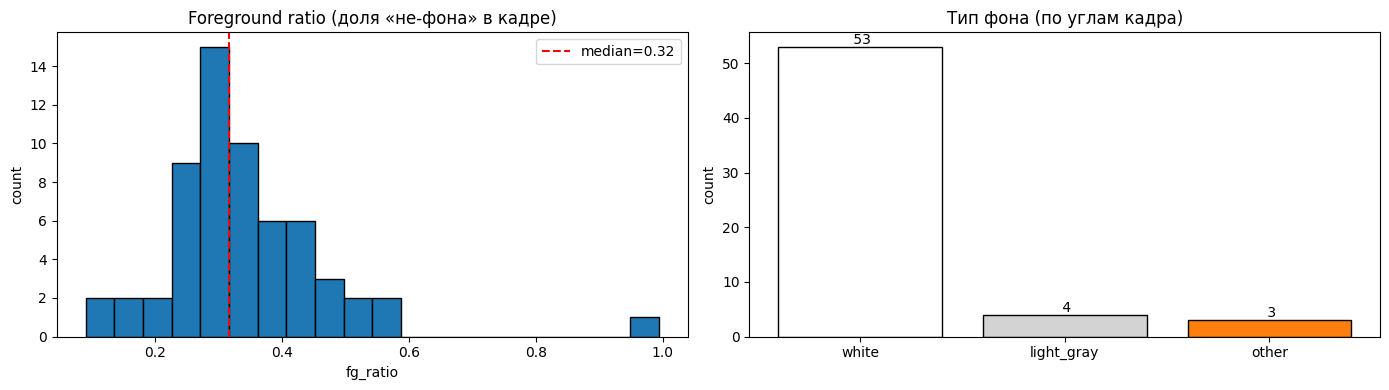

In [28]:
def quick_stats(img_path, max_side=512):
    """Считает foreground_ratio и тип фона по уменьшенной копии."""
    with Image.open(img_path) as im:
        im = im.convert("RGB")
        scale = max_side / max(im.size)
        if scale < 1:
            new_size = (int(im.size[0]*scale), int(im.size[1]*scale))
            im = im.resize(new_size)
        arr = np.asarray(im)  # (H, W, 3)

    H, W = arr.shape[:2]
    margin_h = max(1, int(H * 0.05))
    margin_w = max(1, int(W * 0.05))
    corners = np.concatenate([
        arr[:margin_h, :margin_w].reshape(-1, 3),
        arr[:margin_h, -margin_w:].reshape(-1, 3),
        arr[-margin_h:, :margin_w].reshape(-1, 3),
        arr[-margin_h:, -margin_w:].reshape(-1, 3),
    ])
    bg_mean = corners.mean(axis=0)
    bg_std  = corners.std(axis=0).mean()

    diff = np.abs(arr.astype(np.int16) - bg_mean.astype(np.int16)).sum(axis=2)
    fg_mask = diff > 30
    fg_ratio = fg_mask.mean()

    if bg_mean.mean() > 230 and bg_std < 15:
        bg_type = "white"
    elif bg_mean.mean() > 180 and bg_std < 25:
        bg_type = "light_gray"
    else:
        bg_type = "other"

    return {
        "fg_ratio": float(fg_ratio),
        "bg_mean_r": float(bg_mean[0]),
        "bg_mean_g": float(bg_mean[1]),
        "bg_mean_b": float(bg_mean[2]),
        "bg_std": float(bg_std),
        "bg_type": bg_type,
    }

SAMPLE_N = 60
sample_for_modes = df_long.sample(SAMPLE_N, random_state=SEED).reset_index(drop=True)

stats_rows = []
for _, r in tqdm(sample_for_modes.iterrows(), total=len(sample_for_modes), desc="quick stats"):
    s = quick_stats(ROOT / r["image_file"])
    s.update({"code": r["code"], "name": r["name"], "image_file": r["image_file"]})
    stats_rows.append(s)

stats_df = pd.DataFrame(stats_rows)
print("Распределение fg_ratio:")
print(stats_df["fg_ratio"].describe().round(3))
print("\nbg_type:")
print(stats_df["bg_type"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(stats_df["fg_ratio"], bins=20, edgecolor="black")
axes[0].set_title("Foreground ratio (доля «не-фона» в кадре)")
axes[0].set_xlabel("fg_ratio"); axes[0].set_ylabel("count")
axes[0].axvline(stats_df["fg_ratio"].median(), color="red", linestyle="--", label=f"median={stats_df['fg_ratio'].median():.2f}")
axes[0].legend()

bg_counts = stats_df["bg_type"].value_counts()
axes[1].bar(bg_counts.index, bg_counts.values, color=["white", "lightgray", "C1"][:len(bg_counts)], edgecolor="black")
axes[1].set_title("Тип фона (по углам кадра)")
axes[1].set_ylabel("count")
for i, v in enumerate(bg_counts.values):
    axes[1].text(i, v, f" {v}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("../artifacts/figures/eda_visual_modes.png", dpi=120, bbox_inches="tight")
plt.show()

Распределение режимов на подвыборке 60 картинок:
layout_mode
normal/multi_view    55
small_object          4
close_up              1
Name: count, dtype: int64



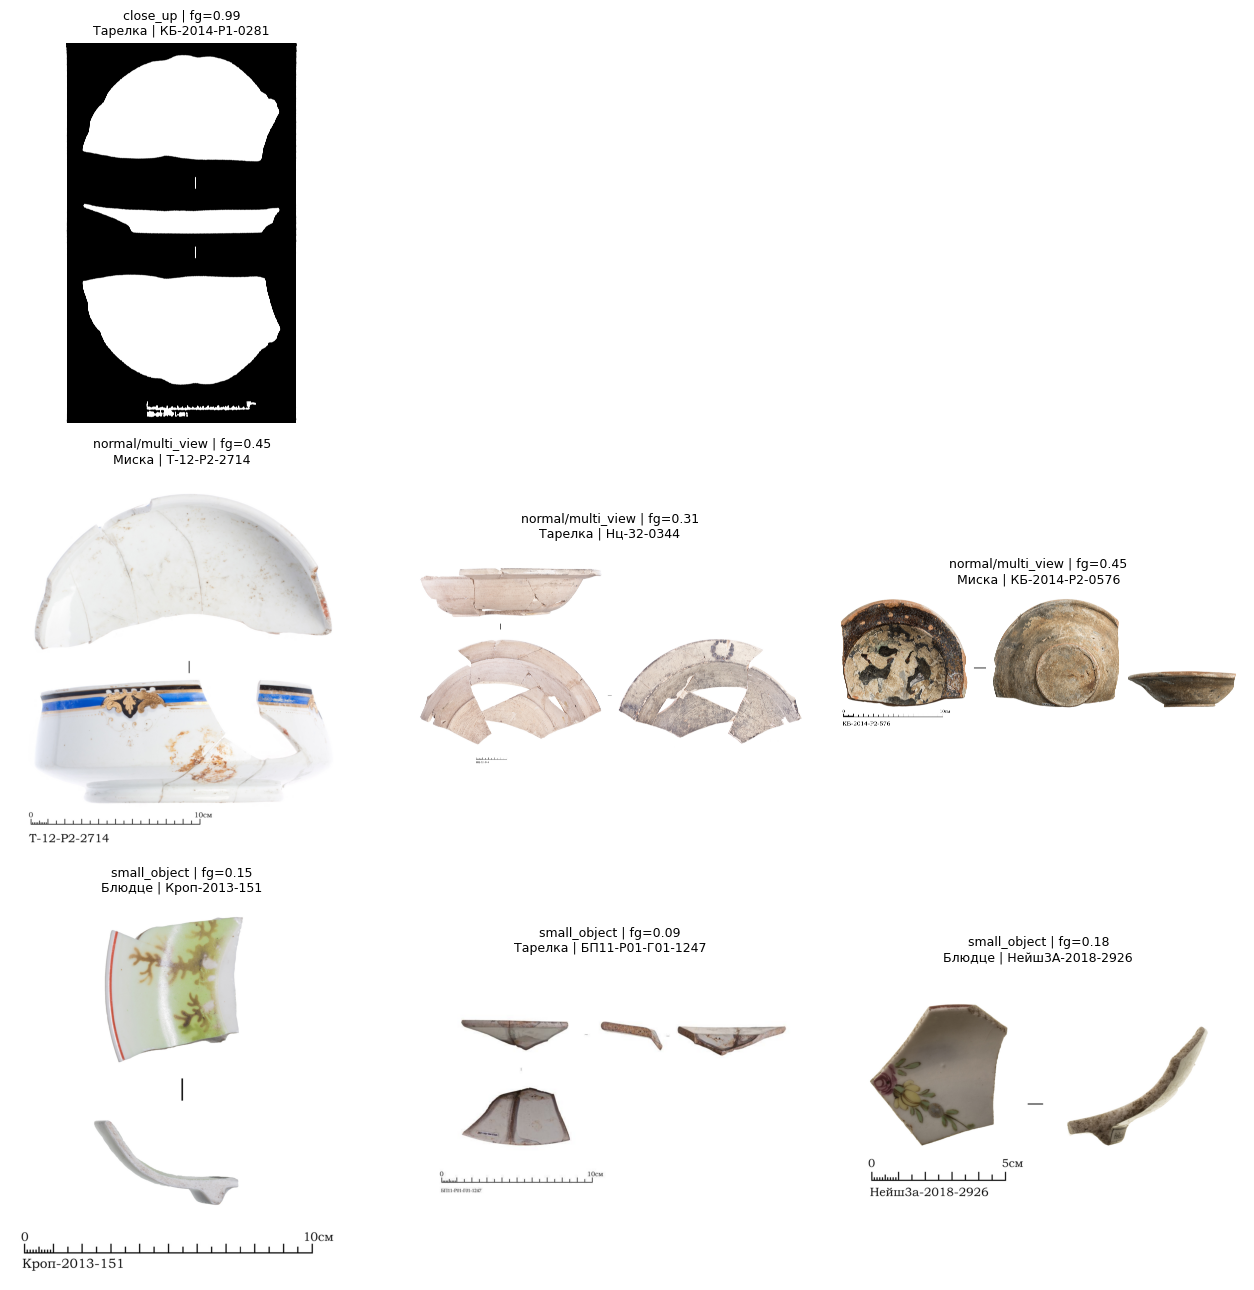

Saved: artifacts/figures/eda_layout_modes.png


In [29]:
def assign_mode(fg, bg):
    if fg > 0.7:
        return "close_up"
    elif fg < 0.18:
        return "small_object"
    else:
        return "normal/multi_view"

stats_df["layout_mode"] = stats_df.apply(lambda r: assign_mode(r["fg_ratio"], r["bg_type"]), axis=1)

print("Распределение режимов на подвыборке 60 картинок:")
print(stats_df["layout_mode"].value_counts())
print()

fig, axes = plt.subplots(3, 3, figsize=(13, 13))

modes_to_show = ["close_up", "normal/multi_view", "small_object"]
for row_idx, mode in enumerate(modes_to_show):
    sub = stats_df[stats_df["layout_mode"] == mode]
    if len(sub) == 0:
        for c in range(3):
            axes[row_idx, c].axis("off")
        axes[row_idx, 0].set_title(f"{mode}: нет примеров", fontsize=11)
        continue
    sub = sub.sample(min(3, len(sub)), random_state=SEED).reset_index(drop=True)
    for col_idx in range(3):
        ax = axes[row_idx, col_idx]
        if col_idx < len(sub):
            r = sub.iloc[col_idx]
            img = Image.open(ROOT / r["image_file"])
            ax.imshow(img)
            ax.axis("off")
            ax.set_title(f"{mode} | fg={r['fg_ratio']:.2f}\n{r['name']} | {r['code']}",
                         fontsize=9)
        else:
            ax.axis("off")

plt.tight_layout()
plt.savefig("../artifacts/figures/eda_layout_modes.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: artifacts/figures/eda_layout_modes.png")

In [30]:
all_stats = []
for img_path in tqdm(img_files, desc="all images"):
    s = quick_stats(img_path)
    s["file"] = img_path.name
    all_stats.append(s)

all_stats_df = pd.DataFrame(all_stats)
all_stats_df["layout_mode"] = all_stats_df.apply(
    lambda r: assign_mode(r["fg_ratio"], r["bg_type"]), axis=1
)

all_stats_df["code"] = all_stats_df["file"].str.replace("_orig.jpg", "", regex=False).apply(normalize)
all_stats_df = all_stats_df.merge(
    df_long[["code", "name", "material"]].drop_duplicates("code"),
    on="code", how="left"
)

print("Распределение режимов по всему корпусу:")
print(all_stats_df["layout_mode"].value_counts())
print()
print("Распределение фона по всему корпусу:")
print(all_stats_df["bg_type"].value_counts())
print()
print("fg_ratio describe:")
print(all_stats_df["fg_ratio"].describe().round(3))

all_stats_df.to_csv("../data/interim/image_visual_stats.csv", index=False)
print("\nSaved: data/interim/image_visual_stats.csv")

all images:   0%|          | 0/1388 [00:00<?, ?it/s]

Распределение режимов по всему корпусу:
layout_mode
normal/multi_view    1288
small_object           68
close_up               32
Name: count, dtype: int64

Распределение фона по всему корпусу:
bg_type
white         1184
light_gray     123
other           81
Name: count, dtype: int64

fg_ratio describe:
count    1388.000
mean        0.334
std         0.136
min         0.070
25%         0.255
50%         0.314
75%         0.383
max         0.998
Name: fg_ratio, dtype: float64

Saved: data/interim/image_visual_stats.csv


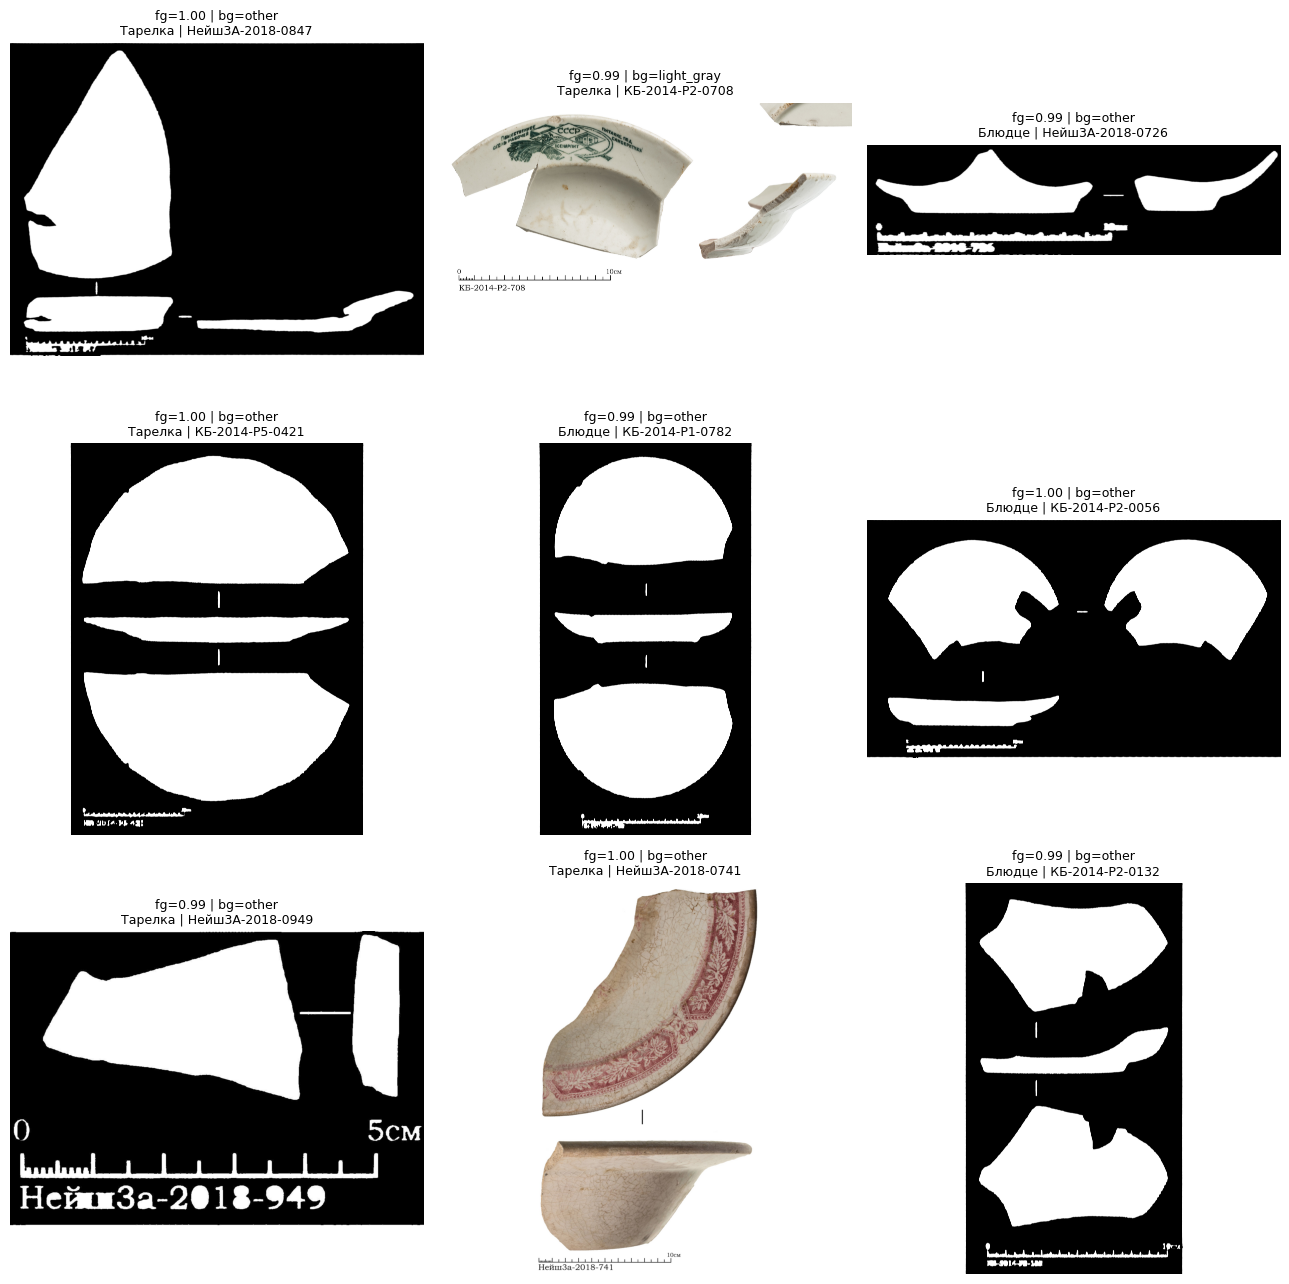

In [31]:
suspect = all_stats_df[all_stats_df["layout_mode"] == "close_up"].sample(
    min(9, 32), random_state=SEED
).reset_index(drop=True)

fig, axes = plt.subplots(3, 3, figsize=(13, 13))
axes = axes.flatten()
for ax, (_, r) in zip(axes, suspect.iterrows()):
    img = Image.open(IMG_DIR / r["file"])
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"fg={r['fg_ratio']:.2f} | bg={r['bg_type']}\n{r.get('name', '?')} | {r['code']}",
                 fontsize=9)
for ax in axes[len(suspect):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("../artifacts/figures/eda_high_fg_outliers.png", dpi=120, bbox_inches="tight")
plt.show()

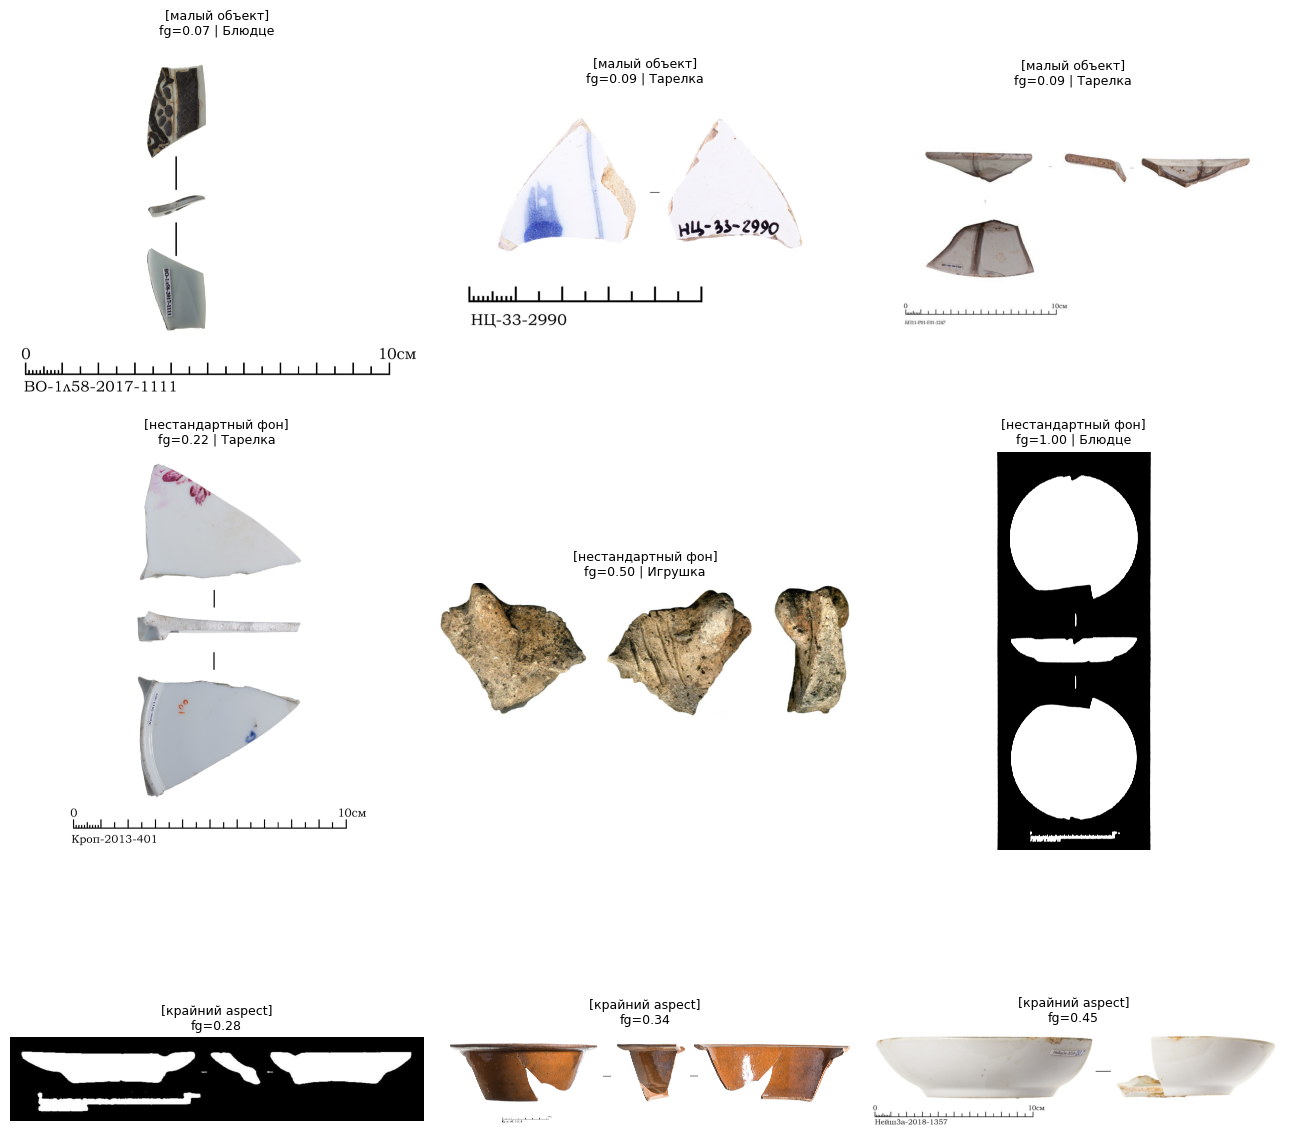

Saved: artifacts/figures/eda_problem_cases.png


In [32]:
small = all_stats_df.nsmallest(3, "fg_ratio")
weird_bg = all_stats_df[all_stats_df["bg_type"] == "other"].sample(3, random_state=SEED)

size_df["code"] = size_df["file"].str.replace("_orig.jpg", "", regex=False).apply(normalize)
extreme_aspect = size_df.merge(all_stats_df[["code", "fg_ratio"]], on="code", how="left")
extreme_aspect = extreme_aspect.nlargest(3, "aspect")

problems = []
for _, r in small.iterrows():
    problems.append(("малый объект", r["file"], r["fg_ratio"], r.get("name")))
for _, r in weird_bg.iterrows():
    problems.append(("нестандартный фон", r["file"], r["fg_ratio"], r.get("name")))
for _, r in extreme_aspect.iterrows():
    problems.append(("крайний aspect", r["file"], r.get("fg_ratio", float("nan")), None))

fig, axes = plt.subplots(3, 3, figsize=(13, 13))
axes = axes.flatten()
for ax, (label, fname, fg, name) in zip(axes, problems):
    img = Image.open(IMG_DIR / fname)
    ax.imshow(img)
    ax.axis("off")
    title = f"[{label}]\nfg={fg:.2f}" + (f" | {name}" if name else "")
    ax.set_title(title, fontsize=9)
for ax in axes[len(problems):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("../artifacts/figures/eda_problem_cases.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: artifacts/figures/eda_problem_cases.png")

In [33]:
def is_mask(stats_row):
    """Бинарная маска: чёрный фон (низкий bg_mean), низкая bg_std, высокий fg_ratio."""
    bg_brightness = (stats_row["bg_mean_r"] + stats_row["bg_mean_g"] + stats_row["bg_mean_b"]) / 3
    return (
        bg_brightness < 50           # тёмный фон
        and stats_row["bg_std"] < 30 # фон однородный
    )

all_stats_df["is_mask"] = all_stats_df.apply(is_mask, axis=1)
print(f"Подозрительных масок в корпусе: {all_stats_df['is_mask'].sum()} / {len(all_stats_df)}")
print(f"Это {100 * all_stats_df['is_mask'].mean():.1f}% корпуса")
print()
print("Маски по типам предметов:")
print(all_stats_df[all_stats_df["is_mask"]]["name"].value_counts())
print()
print("А вот тип предметов в нормальных кадрах:")
print(all_stats_df[~all_stats_df["is_mask"]]["name"].value_counts())

Подозрительных масок в корпусе: 1 / 1388
Это 0.1% корпуса

Маски по типам предметов:
name
Тарелка    1
Name: count, dtype: int64

А вот тип предметов в нормальных кадрах:
name
Тарелка            479
Изразец            361
Блюдце             216
Крышка             177
Миска              113
Плитка              26
Игрушка              6
Тарелка/блюдо        4
Миска (?)            4
Игрушка ёлочная      1
Name: count, dtype: int64


In [34]:
known_masks = [
    "КБ-2014-Р1-0281", "Нейш3А-2018-0847", "КБ-2014-Р5-0421",
    "КБ-2014-Р1-0782", "КБ-2014-Р2-0056", "Нейш3А-2018-0949",
    "Нейш3А-2018-0741", "КБ-2014-Р2-0132", "Нейш3А-2018-0726",
]

codes_norm = [normalize(c) for c in known_masks]

mask_check = all_stats_df[all_stats_df["code"].isin(codes_norm)][
    ["code", "fg_ratio", "bg_mean_r", "bg_mean_g", "bg_mean_b", "bg_std", "bg_type", "layout_mode"]
]
mask_check["bg_brightness"] = (mask_check["bg_mean_r"] + mask_check["bg_mean_g"] + mask_check["bg_mean_b"]) / 3
print(mask_check.round(1).to_string(index=False))

            code  fg_ratio  bg_mean_r  bg_mean_g  bg_mean_b  bg_std bg_type layout_mode  bg_brightness
 КБ-2014-Р1-0281       1.0       13.1       13.1       13.1    48.9   other    close_up           13.1
 КБ-2014-Р1-0782       1.0       16.4       16.4       16.4    54.3   other    close_up           16.4
 КБ-2014-Р2-0056       1.0       21.9       21.9       21.9    65.4   other    close_up           21.9
 КБ-2014-Р2-0132       1.0       15.5       15.5       15.5    53.4   other    close_up           15.5
 КБ-2014-Р5-0421       1.0       15.5       15.5       15.5    55.0   other    close_up           15.5
Нейш3А-2018-0726       1.0       11.5       11.5       11.5    49.0   other    close_up           11.5
Нейш3А-2018-0741       1.0      241.0      239.4      238.0    49.5   other    close_up          239.5
Нейш3А-2018-0847       1.0       24.4       24.4       24.4    68.1   other    close_up           24.4
Нейш3А-2018-0949       1.0       19.3       19.3       19.3    61.2   oth

In [35]:
def is_mask_v2(row):
    bg_b = (row["bg_mean_r"] + row["bg_mean_g"] + row["bg_mean_b"]) / 3
    return row["fg_ratio"] > 0.95 and bg_b < 50

all_stats_df["is_mask"] = all_stats_df.apply(is_mask_v2, axis=1)
print(f"Подозрительных масок: {all_stats_df['is_mask'].sum()} / {len(all_stats_df)}")
print(f"Это {100 * all_stats_df['is_mask'].mean():.1f}% корпуса")
print()
print("Маски по типам предметов:")
print(all_stats_df[all_stats_df["is_mask"]]["name"].value_counts())
print()
print("Маски по сайтам:")
all_stats_df["_site"] = all_stats_df["code"].str.extract(r'^([А-Яа-яA-Za-z]+\d*)')
print(all_stats_df[all_stats_df["is_mask"]]["_site"].value_counts())

Подозрительных масок: 28 / 1388
Это 2.0% корпуса

Маски по типам предметов:
name
Тарелка    14
Блюдце     12
Плитка      1
Крышка      1
Name: count, dtype: int64

Маски по сайтам:
_site
КБ       16
Нейш3    10
ВО        2
Name: count, dtype: int64


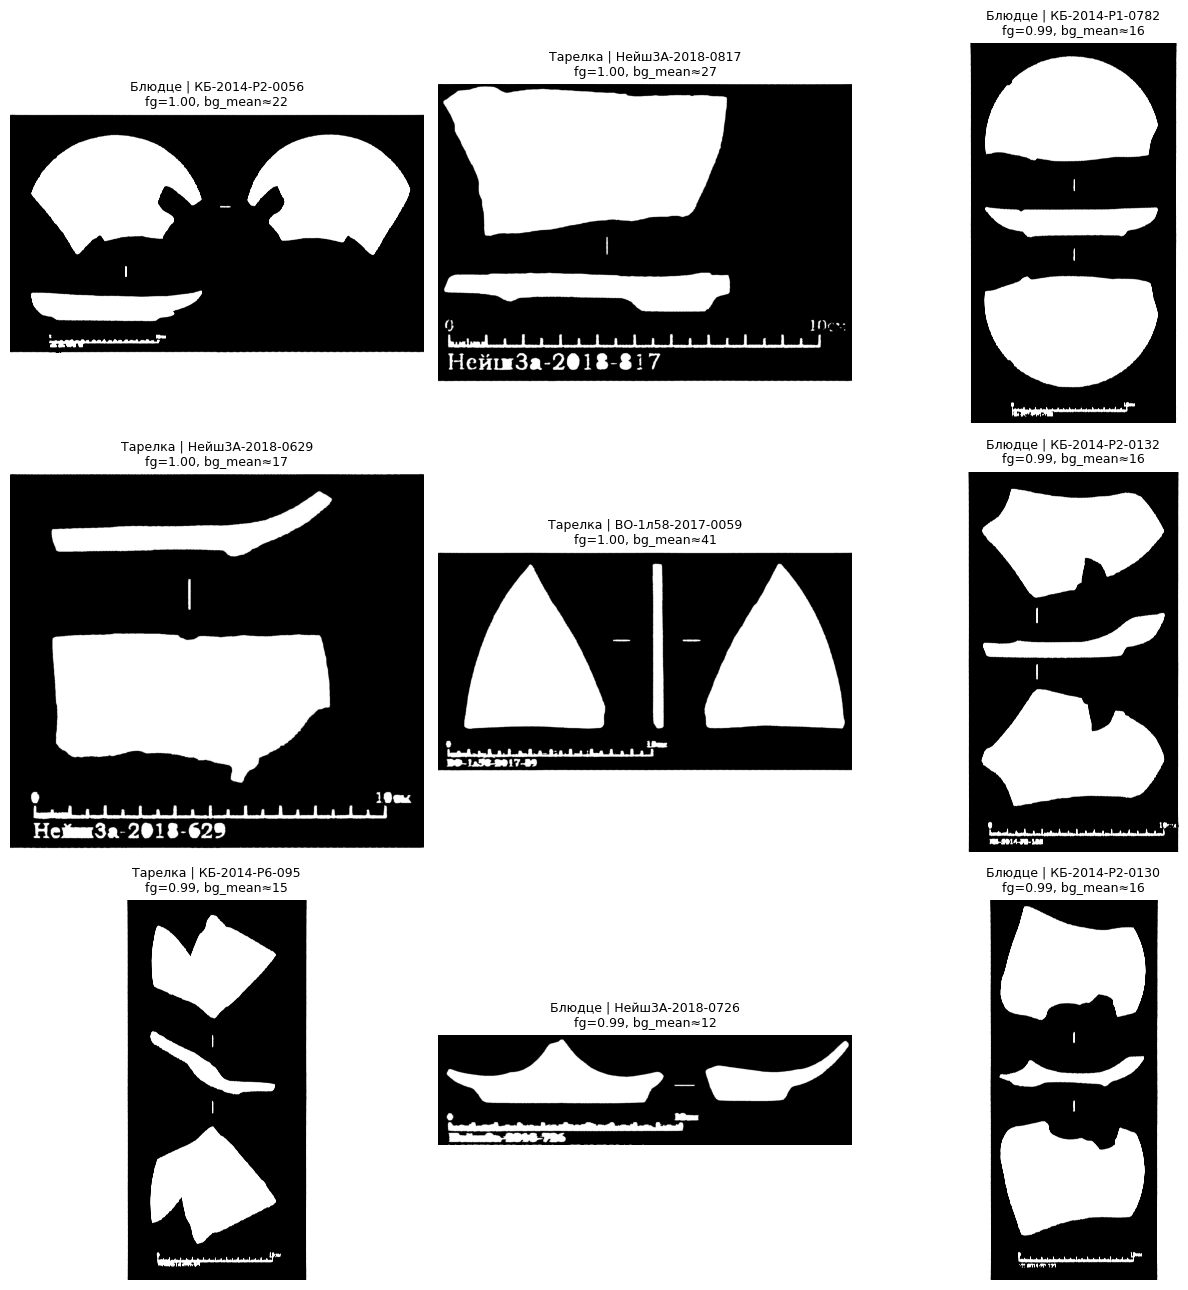

Saved: artifacts/figures/eda_detected_masks.png  (9 samples)


In [36]:
masks_sample = all_stats_df[all_stats_df["is_mask"]].sample(
    min(9, all_stats_df["is_mask"].sum()), random_state=SEED
).reset_index(drop=True)

fig, axes = plt.subplots(3, 3, figsize=(13, 13))
axes = axes.flatten()
for ax, (_, r) in zip(axes, masks_sample.iterrows()):
    img = Image.open(IMG_DIR / r["file"])
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"{r['name']} | {r['code']}\nfg={r['fg_ratio']:.2f}, bg_mean≈{(r['bg_mean_r']+r['bg_mean_g']+r['bg_mean_b'])/3:.0f}",
                 fontsize=9)
for ax in axes[len(masks_sample):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("../artifacts/figures/eda_detected_masks.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: artifacts/figures/eda_detected_masks.png  ({len(masks_sample)} samples)")

In [37]:
mask_codes = set(all_stats_df.loc[all_stats_df["is_mask"], "code"])
df_long["is_mask"] = df_long["group_key"].apply(lambda c: c in mask_codes)

print(f"Записей помечено как mask: {df_long['is_mask'].sum()} / {len(df_long)}")
print(f"После исключения остаётся: {(~df_long['is_mask']).sum()} записей")

df_long.to_csv("../data/interim/items_with_images.csv", index=False)
print("Saved: data/interim/items_with_images.csv (с колонкой is_mask)")

Записей помечено как mask: 28 / 1389
После исключения остаётся: 1361 записей
Saved: data/interim/items_with_images.csv (с колонкой is_mask)


## Задания 1-4. Резюме EDA

### Объём корпуса
- 1389 строк CSV ↔ 1388 уникальных файлов изображений (1 дубль `code=46858`)
- Покрытие 100% после исправления mojibake (NFD → NFC) и возврата файла без префикса
- 14 различных «сайтов» (раскопов) по префиксу инвентарного кода

### Поля и распределения
- **тип (`name`)** — 10 классов, длинный хвост: топ-5 покрывают 96% (Тарелка 480, Изразец 361, Блюдце 216, Крышка 177, Миска 113); требует объединения вариантов («Миска (?)» → «Миска» и т.п.)
- **материал (`material`)** — 21 класс, экстремальный дисбаланс: топ-3 (Керамика, Фаянс, Фарфор) = 92% корпуса; остальные 18 — длинный хвост, требует группировки
- **целостность (`fragm`)** — 2 класса, дисбаланс 90:10 (Фрагмент 1258 / Целый 129); 2 NaN
- **описание** — медиана 9 слов, max 31 слово; язык формализован

### Физические параметры изображений
- Размеры: median **4671×3654 px**, max **18808×14212 px** (до 184 МП)
- Длинная сторона: median 5760 px → resize до 224 даёт коэффициент ~25
- Aspect ratio: median 1.32, диапазон 0.26–4.95 (от вытянутых-«портретных» до вытянутых-«альбомных»)
- ⚠️ Нужно поднимать `Image.MAX_IMAGE_PIXELS = None` в Pillow

### Visual modes
Эвристика по углам кадра + `fg_ratio` на всех 1388 файлах:
- **normal/multi-view** — 1288 (92.8%)
- **small_object** — 68 (4.9%) — мелкий объект на пустом холсте, риск потерять детали при resize
- **close_up по эвристике** — 32, но **31 из них оказались бинарными масками**, не close-up'ами клейм
- В корпусе **нет настоящих close-up'ов клейм/надписей** как отдельных снимков — клейма видны только внутри multi-view карточек

### 🚨 Бинарные маски (28 шт., 2.0%)
Систематическая аномалия: **силуэты на чёрном фоне** вместо фотографий
- Распределение по типам: Тарелка 14, Блюдце 12, Плитка 1, Крышка 1
- Распределение по сайтам: КБ 16, Нейш3 10, ВО 2
- Сосредоточены в крупных классах → **критический shortcut-риск**: модель может выучить «чёрный фон → Тарелка/Блюдце»
- **Решение: исключаются из train/val/test_open** через флаг `is_mask` в `data/interim/items_with_images.csv`

### Shortcut-риски в pipeline
1. **Масштабная линейка + подпись инвентарного номера** на ВСЕХ нормальных карточках — модель может «читать» подпись
2. **Бинарные маски** — обработаны выше, исключаются
3. **Большая доля пустого фона** — медиана `fg_ratio` = 0.31, объект занимает ~треть кадра

### Выводы для preprocessing (Задание 9)
- ✅ Resize **longest-side + pad** (не CenterCrop, не resize в квадрат)
- ✅ Никакой агрессивной цветовой аугментации (полива, ангоб, цвет — целевые признаки)
- ✅ Никакой инверсии всего изображения
- ✅ Никакого mosaic между разными артефактами
- ⚠️ Background standardization не нужна — фон уже однороден (85% white)
- 💡 Content-aware crop по foreground bbox — кандидат для ablation

In [38]:
sample_descs = (
    df_long[~df_long["is_mask"]]
    .dropna(subset=["description"])
    .sample(20, random_state=SEED)
    .reset_index(drop=True)
)

print("Случайные 20 описаний из корпуса:\n")
for i, r in sample_descs.iterrows():
    print(f"[{i+1:2d}] name={r['name']:15s} | material={r['material']:25s}")
    print(f"     desc: {r['description']}")
    print()

Случайные 20 описаний из корпуса:

[ 1] name=Тарелка         | material=Фаянс                    
     desc: Тарелки фаянсовой профиль

[ 2] name=Тарелка         | material=Керамика                 
     desc: Тарелки светлоглиняной толстостенной с темно-зеленой поливой и рельефным растительным орнаментом снаружи (коричневый, черный) и темно-зеленой и коричневой поливой внутри венчика фр-т

[ 3] name=Миска (?)       | material=Фаянс                    
     desc: Сосуда (миски ?) фаянсовой  с бежевой поливой внутри и снаружи венчика фр-т

[ 4] name=Тарелка         | material=Стекло                   
     desc: Тарелки (?) стеклянной края фр-т

[ 5] name=Миска           | material=Керамика                 
     desc: Миски красноглиняной профиль

[ 6] name=Миска           | material=Керамика                 
     desc: Миска красноглиняная со светло-желтой поливой внутри и частичной коричневой снаружи фр-ая

[ 7] name=Изразец         | material=Керамика                 
     desc: Изра

In [40]:
PART_RULES = [
    (r"придонн",     "придонная_часть"),
    (r"венчик",      "венчик"),
    (r"донц|днищ",   "донце"),
    (r"горл",        "горлышко"),
    (r"ручк",        "ручка"),
    (r"стенк",       "стенка"),
    (r"профил",      "профиль"),
    (r"тулов",       "тулово"),
    (r"ножк",        "ножка"),
    (r"крышк",       "крышка"),
    (r"край",        "край"),
    (r"фр-т|фрагмент", "общий_фрагмент"),
]

def extract_part(desc):
    if pd.isna(desc):
        return None
    d = desc.lower()
    for pattern, label in PART_RULES:
        if re.search(pattern, d):
            return label
    return None

df_long["part_extracted"] = df_long["description"].apply(extract_part)

# Распределение
part_dist = df_long.loc[~df_long["is_mask"], "part_extracted"].value_counts(dropna=False)
print("Распределение извлечённой 'части' (без масок):")
print(part_dist)
print(f"\nДоля записей с какой-то меткой части: {df_long.loc[~df_long['is_mask'], 'part_extracted'].notna().mean():.1%}")

Распределение извлечённой 'части' (без масок):
part_extracted
общий_фрагмент     456
профиль            279
донце              170
венчик             160
крышка              97
NaN                 96
ручка               45
придонная_часть     42
стенка              13
ножка                2
край                 1
Name: count, dtype: int64

Доля записей с какой-то меткой части: 92.9%


In [41]:
no_part = df_long[(~df_long["is_mask"]) & df_long["part_extracted"].isna()]
print(f"Без извлечённой части: {len(no_part)} записей")
print()
print("Их fragm-распределение:")
print(no_part["fragm"].value_counts(dropna=False))
print()
print("Примеры описаний (первые 10):")
for _, r in no_part.head(10).iterrows():
    print(f"  [{r['name']:15s} | {str(r['fragm']):10s}] {r['description']}")

Без извлечённой части: 96 записей

Их fragm-распределение:
fragm
Целый       72
Фрагмент    22
NaN          2
Name: count, dtype: int64

Примеры описаний (первые 10):
  [Плитка          | Целый     ] Плитка керамическая с белой поливой и зеленым подглазурным растительно-геометрическим орнаментом, клейменая
  [Плитка          | Целый     ] Плитка бетонно-композитная напольная, орнаментированная
  [Плитка          | Целый     ] Плитка бетонно-композитная напольная, орнаментированная
  [Плитка          | Целый     ] Плитка метлахская восьмиугольная белого цвета с надписью на тыльной стороне 
  [Тарелка         | Фрагмент  ] Тарелки фаянсовой с полихромной росписью и рельефным краем
  [Блюдце          | Целый     ] Блюдце фаянсовое с зеленой росписью
  [Миска           | Целый     ] Миска светлоглиняная
  [Плитка          | Целый     ] Плитка светлоглиняная напольная с растительным вдавленным рисунком
  [Тарелка         | Фрагмент  ] Тарелки фарфоровой с золотой каймой по краю и изображени

In [42]:
def finalize_part(row):
    # Маски не обрабатываем
    if row["is_mask"]:
        return None

    fragm = row["fragm"]
    extracted = row["part_extracted"]

    # 1. Целые предметы — отдельный класс
    if fragm == "Целый":
        return "целый_предмет"

    # 2. Если ничего не извлекли — общий фрагмент (только если fragm == "Фрагмент")
    if pd.isna(extracted):
        if fragm == "Фрагмент":
            return "общий_фрагмент"
        return None  # NaN fragm + ничего не извлекли — действительно неизвестно

    # 3. Редкие классы → "другое"
    rare = {"стенка", "ножка", "край"}
    if extracted in rare:
        return "другое"

    return extracted

df_long["part_norm"] = df_long.apply(finalize_part, axis=1)

part_final = df_long.loc[~df_long["is_mask"], "part_norm"].value_counts(dropna=False)
print("Финальное распределение поля 'часть':")
print(part_final)
print()
print(f"Покрытие (не-NaN): {df_long.loc[~df_long['is_mask'], 'part_norm'].notna().mean():.1%}")
print(f"Число классов:    {df_long.loc[~df_long['is_mask'], 'part_norm'].nunique()}")

Финальное распределение поля 'часть':
part_norm
общий_фрагмент     476
профиль            278
донце              164
венчик             157
целый_предмет      126
крышка              68
придонная_часть     42
ручка               32
другое              16
NaN                  2
Name: count, dtype: int64

Покрытие (не-NaN): 99.9%
Число классов:    9


## Задание 5. Итог: выбранные поля для baseline

### Поля, которые берём (4 шт.)

| Поле | Источник | Почему визуально извлекаемо | Тип цели | Кол-во классов | Доля пропусков | Риск неоднозначности |
|---|---|---|---|---|---|---|
| **тип** | `name` | Форма, силуэт, наличие/отсутствие края, отверстия и т.д. напрямую видны на изображении | single-label | 7 (после нормализации: «Миска (?)» → «Миска», «Игрушка ёлочная» → «Игрушка», «Тарелка/блюдо» → отдельный класс или «Тарелка»; финал в Задании 6) | 0 | средний — фрагменты могут быть похожи между собой (тарелка/блюдце по донцу) |
| **материал** | `material` | Цвет излома, фактура, прозрачность, блеск глазури — визуальные признаки. Но субтипы керамики (красноглиняная/белоглиняная) часто не различить уверенно | single-label | 5–6 (после группировки длинного хвоста: керамика / фаянс / фарфор / стекло / прочее; финал в Задании 6) | 0 | высокий на тонких субтипах → schлопываем хвост |
| **целостность** | `fragm` | Видно по контуру: целый или со сколами/обломами | single-label, бинарная | 2 (Фрагмент / Целый) | 2 строки (~0.1%) | низкий |
| **часть** | `description` (regex) → `part_norm` | Венчик, донце, стенка, профиль, ручка различимы визуально по форме фрагмента | single-label | 9 (общий_фрагмент, профиль, донце, венчик, целый_предмет, крышка, придонная_часть, ручка, другое) | 0.1% | средний — близкие фрагменты («профиль» vs «венчик») сложно отличить на маленькой картинке |

### Поля, которые сознательно НЕ берём в baseline

| Поле | Почему исключаем |
|---|---|
| **функция** (например, «помадная», «облицовочная») | Из визуала почти не читается. Помадная банка от обычной отличается по контексту, а не по форме. |
| **технология изготовления** (например, «кованый») | Сильно зависит от состояния поверхности. На корродированном металле «кованый/литой» неочевиден даже эксперту по фото. |
| **датировка / культурный слой** | Не визуальный признак вообще; зависит от археологического контекста (`cultlayer` в csv — это контекст, не визуал). |
| **типологические подтипы** (метлахская, восьмиугольная, плоская и т.п.) | Тонкая семантика, требует обширной разметки. В baseline без неё. |
| **размеры** | На фото без масштабной линейки не оценить; а если по линейке — это shortcut, который рискуем закрепить. |
| **покрытие, цвет покрытия, локализация, декор** | Извлекаемы из визуала и потенциально полезны, но в **обязательный** baseline не берём. Кандидаты на расширение, если время позволит — добавим как extra-поля или в шаблон auto_description через regex из описания. |

### Логика выбора

Главный принцип SIMILIS: **«хороший baseline — это минимум честно предсказываемых полей, а не максимум»**. Берём только то, что:
1. Видно на фото без экспертного контекста
2. Имеет относительно стабильную разметку в корпусе
3. Покрывает 95%+ записей

После исключения **28 бинарных масок** (см. Задание 4) и при покрытии 99.9% по полю «часть» получаем **рабочую выборку 1361 запись × 4 поля** — этого более чем достаточно для baseline-обучения.

In [43]:
df_long.to_csv("../data/interim/items_with_images.csv", index=False)
print(f"Saved: data/interim/items_with_images.csv")
print(f"Колонки: {df_long.columns.tolist()}")

Saved: data/interim/items_with_images.csv
Колонки: ['code', 'name', 'description', 'material', 'size', 'fragm', 'cultlayer', 'image_file', 'group_key', 'is_mask', 'part_extracted', 'part_norm']


In [44]:
NAME_DICT = {
    "Тарелка":         ("Тарелка",   False),
    "Изразец":         ("Изразец",   False),
    "Блюдце":          ("Блюдце",    False),
    "Крышка":          ("Крышка",    False),
    "Миска":           ("Миска",     False),
    "Плитка":          ("Плитка",    False),
    "Игрушка":         ("Игрушка",   False),
    "Миска (?)":       ("Миска",     True),
    "Игрушка ёлочная": ("Игрушка",   False),
    "Тарелка/блюдо":   ("Тарелка",   True),
}

def norm_name(raw):
    if pd.isna(raw):
        return pd.Series({"name_norm": None, "name_is_uncertain": False, "name_is_missing": True})
    norm, uncertain = NAME_DICT.get(str(raw), (str(raw), False))
    return pd.Series({"name_norm": norm, "name_is_uncertain": uncertain, "name_is_missing": False})

df_long[["name_norm", "name_is_uncertain", "name_is_missing"]] = df_long["name"].apply(norm_name)

mask_filter = ~df_long["is_mask"]
print("Распределение name_norm (без масок):")
print(df_long.loc[mask_filter, "name_norm"].value_counts(dropna=False))
print(f"\nЧисло классов: {df_long.loc[mask_filter, 'name_norm'].nunique()}")
print(f"Записей с флагом uncertain: {df_long.loc[mask_filter, 'name_is_uncertain'].sum()}")

print("\n--- Словарь raw → norm ---")
for raw, (norm, uncertain) in NAME_DICT.items():
    print(f"  {raw!r:25s} → {norm!r:15s}  (uncertain={uncertain})")

Распределение name_norm (без масок):
name_norm
Тарелка    470
Изразец    361
Блюдце     204
Крышка     176
Миска      117
Плитка      25
Игрушка      8
Name: count, dtype: int64

Число классов: 7
Записей с флагом uncertain: 8

--- Словарь raw → norm ---
  'Тарелка'                 → 'Тарелка'        (uncertain=False)
  'Изразец'                 → 'Изразец'        (uncertain=False)
  'Блюдце'                  → 'Блюдце'         (uncertain=False)
  'Крышка'                  → 'Крышка'         (uncertain=False)
  'Миска'                   → 'Миска'          (uncertain=False)
  'Плитка'                  → 'Плитка'         (uncertain=False)
  'Игрушка'                 → 'Игрушка'        (uncertain=False)
  'Миска (?)'               → 'Миска'          (uncertain=True)
  'Игрушка ёлочная'         → 'Игрушка'        (uncertain=False)
  'Тарелка/блюдо'           → 'Тарелка'        (uncertain=True)


In [45]:
MATERIAL_DICT = {
    "Керамика":                 "Керамика",
    "Красноглиняная керамика":  "Керамика",
    "Белоглиняная керамика":    "Керамика",
    "Светлоглиняная керамика":  "Керамика",
    "Серолощеная керамика":     "Керамика",
    "Каменная масса":           "Керамика",

    "Фаянс":  "Фаянс",
    "Фарфор": "Фарфор",
    "Стекло": "Стекло",
    "Глина":  "Глина",
    "Дерево": "Дерево",

    "Песчаник": "Камень",
    "Сланец":   "Камень",
    "Гранит":   "Камень",
    "Камень":   "Камень",

    "Бронза":       "Металл",
    "Белый металл": "Металл",
    "Металл":       "Металл",

    "Резина":     "Прочее",
    "Пластмасса": "Прочее",
    "Основание - бетон, покрытие - композитный материал": "Прочее",
}

def norm_material(raw):
    if pd.isna(raw):
        return pd.Series({"material_norm": None, "material_is_missing": True})
    norm = MATERIAL_DICT.get(str(raw))
    if norm is None:
        return pd.Series({"material_norm": "Прочее", "material_is_missing": False})
    return pd.Series({"material_norm": norm, "material_is_missing": False})

df_long[["material_norm", "material_is_missing"]] = df_long["material"].apply(norm_material)

print("Группировка материалов (raw → norm):")
mask_filter = ~df_long["is_mask"]
mapping_check = df_long[mask_filter].groupby(["material_norm", "material"]).size().reset_index(name="count")
mapping_check = mapping_check.sort_values(["material_norm", "count"], ascending=[True, False])
print(mapping_check.to_string(index=False))

print("\n\nИтоговое распределение material_norm (без масок):")
print(df_long.loc[mask_filter, "material_norm"].value_counts(dropna=False))
print(f"\nЧисло классов: {df_long.loc[mask_filter, 'material_norm'].nunique()}")

Группировка материалов (raw → norm):
material_norm                                           material  count
        Глина                                              Глина     28
       Дерево                                             Дерево      9
       Камень                                           Песчаник      3
       Камень                                             Сланец      2
       Камень                                             Гранит      1
       Камень                                             Камень      1
     Керамика                                           Керамика    601
     Керамика                            Красноглиняная керамика     21
     Керамика                              Белоглиняная керамика      4
     Керамика                                     Каменная масса      3
     Керамика                            Светлоглиняная керамика      2
     Керамика                               Серолощеная керамика      1
       Металл              

In [46]:
MATERIAL_DICT = {
    # керамика и её подтипы
    "Керамика":                 "Керамика",
    "Красноглиняная керамика":  "Керамика",
    "Белоглиняная керамика":    "Керамика",
    "Светлоглиняная керамика":  "Керамика",
    "Серолощеная керамика":     "Керамика",
    "Каменная масса":           "Керамика",

    # отдельные крупные классы
    "Фаянс":  "Фаянс",
    "Фарфор": "Фарфор",
    "Стекло": "Стекло",
    "Глина":  "Глина",

    # хвост → Прочее (всё, кроме топ-5)
    "Дерево":       "Прочее",
    "Песчаник":     "Прочее",
    "Сланец":       "Прочее",
    "Гранит":       "Прочее",
    "Камень":       "Прочее",
    "Бронза":       "Прочее",
    "Белый металл": "Прочее",
    "Металл":       "Прочее",
    "Резина":       "Прочее",
    "Пластмасса":   "Прочее",
    "Основание - бетон, покрытие - композитный материал": "Прочее",
}

def norm_material(raw):
    if pd.isna(raw):
        return pd.Series({"material_norm": None, "material_is_missing": True})
    norm = MATERIAL_DICT.get(str(raw), "Прочее")  # неизвестное → Прочее
    return pd.Series({"material_norm": norm, "material_is_missing": False})

df_long[["material_norm", "material_is_missing"]] = df_long["material"].apply(norm_material)

mask_filter = ~df_long["is_mask"]
print("Итоговое распределение material_norm (без масок):")
print(df_long.loc[mask_filter, "material_norm"].value_counts(dropna=False))
print(f"\nЧисло классов: {df_long.loc[mask_filter, 'material_norm'].nunique()}")

Итоговое распределение material_norm (без масок):
material_norm
Керамика    632
Фаянс       360
Фарфор      289
Стекло       28
Глина        28
Прочее       24
Name: count, dtype: int64

Число классов: 6


## Задание 6. Нормализация словарей и сбор целевых колонок

### Итоговые словари нормализации

#### name (тип предмета): 7 классов

| raw value         | norm value | uncertain |
|-------------------|------------|-----------|
| Тарелка           | Тарелка    | False     |
| Изразец           | Изразец    | False     |
| Блюдце            | Блюдце     | False     |
| Крышка            | Крышка     | False     |
| Миска             | Миска      | False     |
| Плитка            | Плитка     | False     |
| Игрушка           | Игрушка    | False     |
| Миска (?)         | Миска      | **True**  |
| Игрушка ёлочная   | Игрушка    | False     |
| Тарелка/блюдо     | Тарелка    | **True**  |

#### material: 6 классов (длинный хвост → "Прочее")

| norm value | raw values, входящие в группу |
|------------|------------------------------|
| Керамика   | Керамика, Красноглиняная керамика, Белоглиняная керамика, Светлоглиняная керамика, Серолощеная керамика, Каменная масса |
| Фаянс      | Фаянс |
| Фарфор     | Фарфор |
| Стекло     | Стекло |
| Глина      | Глина |
| Прочее     | Дерево, Песчаник, Сланец, Гранит, Камень, Бронза, Белый металл, Металл, Резина, Пластмасса, бетон-композит |

**Логика группировки:**
- Керамические подтипы (красноглиняная, белоглиняная и т.п.) визуально часто неразличимы на фрагментах → схлопнуты
- Хвост (≤9 записей на класс) сведён в «Прочее» — обучить классификатор различать редкие материалы на 1–9 примерах нереалистично

#### fragm (целостность): 2 класса
Без изменений: Фрагмент / Целый. 2 NaN остаются как `fragm_is_missing`.

#### part_norm (часть): 9 классов
Сделано в Задании 5: общий_фрагмент / профиль / донце / венчик / целый_предмет / крышка / придонная_часть / ручка / другое.

### Вспомогательные колонки
- `<field>_is_missing` — пропуск на входе
- `<field>_is_uncertain` — пометка неопределённости («?» в исходном raw)
- `is_mask` — флаг бинарной маски (Задание 4)

In [47]:
df_long.to_csv("../data/interim/items_with_images.csv", index=False)
print(f"Saved: data/interim/items_with_images.csv")
print(f"Колонки: {df_long.columns.tolist()}")
print(f"Всего записей: {len(df_long)}, рабочих (без масок): {(~df_long['is_mask']).sum()}")

Saved: data/interim/items_with_images.csv
Колонки: ['code', 'name', 'description', 'material', 'size', 'fragm', 'cultlayer', 'image_file', 'group_key', 'is_mask', 'part_extracted', 'part_norm', 'name_norm', 'name_is_uncertain', 'name_is_missing', 'material_norm', 'material_is_missing']
Всего записей: 1389, рабочих (без масок): 1361


## Задание 7. Шаблон auto_description

Шаблон фиксируем **до обучения**, чтобы избежать утечки через подгонку под результаты модели.

### Структура

- **TYPE_GEN** (обязательно): тип в род. падеже — «Тарелки», «Изразца», «Блюдца» и т.д.
- **MATERIAL_ADJ** (обязательно): материал прилагательным — «фаянсовой», «керамической», «фарфорового» и т.д. (согласование рода с типом)
- **PART_OR_INTEGRITY** (обязательно, зависит от двух полей):
  - целый предмет → `целый`
  - фрагмент общий → `фр-т`
  - конкретная часть → `{часть} фр-т` (например, «венчик фр-т»)

### Правила уверенности

Для каждого поля задан порог `T_field`. Если `confidence_field < T_field`:

- **тип**: добавляем `(?)` после значения — «Тарелки (?) фаянсовой профиль фр-т»
- **материал**: пропускаем поле полностью — «Тарелки венчик фр-т»
- **часть**: используем грубый fallback `фр-т` (общий фрагмент)
- **целостность**: если уверенность низкая — считаем фрагментом (доминирующий класс)

Пороги стартовые: `T_type = T_material = 0.6`, `T_part = T_fragm = 0.5`. Откалибруем при необходимости в Задании 17.

In [48]:
# Род предметов (для согласования "красноглиняной" / "красноглиняного")
TYPE_GENDER = {
    "Тарелка":  "f",   # тарелки фаянсовой
    "Изразец":  "m",   # изразца фаянсового
    "Блюдце":   "n",   # блюдца фаянсового
    "Крышка":   "f",   # крышки фаянсовой
    "Миска":    "f",   # миски фаянсовой
    "Плитка":   "f",   # плитки фаянсовой
    "Игрушка":  "f",   # игрушки фаянсовой
}

# Тип в родительном падеже
TYPE_GEN = {
    "Тарелка":  "Тарелки",
    "Изразец":  "Изразца",
    "Блюдце":   "Блюдца",
    "Крышка":   "Крышки",
    "Миска":    "Миски",
    "Плитка":   "Плитки",
    "Игрушка":  "Игрушки",
}

# Материал прилагательным с учётом рода
# {material_norm: {gender: adj_form}}
MATERIAL_ADJ = {
    "Керамика": {"f": "керамической", "m": "керамического", "n": "керамического"},
    "Фаянс":    {"f": "фаянсовой",    "m": "фаянсового",    "n": "фаянсового"},
    "Фарфор":   {"f": "фарфоровой",   "m": "фарфорового",   "n": "фарфорового"},
    "Стекло":   {"f": "стеклянной",   "m": "стеклянного",   "n": "стеклянного"},
    "Глина":    {"f": "глиняной",     "m": "глиняного",     "n": "глиняного"},
    "Прочее":   {"f": "",             "m": "",              "n": ""}, 
}

# Часть → текстовая форма
PART_TEXT = {
    "общий_фрагмент":   "фр-т",
    "профиль":          "профиль фр-т",
    "донце":            "донце фр-т",
    "венчик":           "венчик фр-т",
    "целый_предмет":    "целый",
    "крышка":           "крышка фр-т",
    "придонная_часть":  "придонная часть фр-т",
    "ручка":            "ручка фр-т",
    "другое":           "фр-т",
}

print("Словари определены:")
print(f"  TYPE_GENDER:   {len(TYPE_GENDER)} классов")
print(f"  TYPE_GEN:      {len(TYPE_GEN)} классов")
print(f"  MATERIAL_ADJ:  {len(MATERIAL_ADJ)} классов × 3 рода")
print(f"  PART_TEXT:     {len(PART_TEXT)} классов")

Словари определены:
  TYPE_GENDER:   7 классов
  TYPE_GEN:      7 классов
  MATERIAL_ADJ:  6 классов × 3 рода
  PART_TEXT:     9 классов


In [51]:
from dataclasses import dataclass
from typing import Optional

@dataclass
class FieldPrediction:
    """Один предсказанный класс с уверенностью."""
    value: Optional[str]
    confidence: float = 1.0

THRESHOLDS = {
    "type":     0.6,
    "material": 0.6,
    "part":     0.5,
    "fragm":    0.5,
}

def build_auto_description(
    type_pred:     FieldPrediction,
    material_pred: FieldPrediction,
    part_pred:     FieldPrediction,
    fragm_pred:    FieldPrediction,
    thresholds=THRESHOLDS,
) -> str:
    """
    Собирает auto_description по 4 предсказанным полям с учётом уверенности.
    
    Логика правил уверенности:
    - тип: ниже порога → добавляем "(?)"
    - материал: ниже порога → пропускаем
    - часть: ниже порога → fallback "фр-т"
    - целостность: ниже порога → считаем фрагментом
    """
    parts = []  # компоненты итоговой строки

    # 1. TYPE_GEN — обязательно
    if type_pred.value is None or type_pred.value not in TYPE_GEN:
        type_str = "Предмет"  # самый общий fallback
    else:
        type_str = TYPE_GEN[type_pred.value]
    if type_pred.confidence < thresholds["type"]:
        type_str += " (?)"
    parts.append(type_str)

    # 2. MATERIAL_ADJ — пропускается при низкой уверенности или если "Прочее"
    gender = TYPE_GENDER.get(type_pred.value, "f")  # по умолчанию женский
    if material_pred.value is not None \
       and material_pred.confidence >= thresholds["material"] \
       and material_pred.value in MATERIAL_ADJ:
        adj = MATERIAL_ADJ[material_pred.value][gender]
        if adj:  # пустая строка для "Прочее" — не добавляем
            parts.append(adj)

    # 3. PART/INTEGRITY — обязательно, с fallback на "фр-т"
    # Целостность важнее части: если предсказан "целый" — игнорируем part
    fragm_low_conf = fragm_pred.confidence < thresholds["fragm"]
    is_whole = (fragm_pred.value == "Целый" and not fragm_low_conf)

    if is_whole:
        parts.append("целый")
    else:
        if part_pred.value is None or part_pred.confidence < thresholds["part"]:
            parts.append("фр-т")  # fallback
        else:
            parts.append(PART_TEXT.get(part_pred.value, "фр-т"))

    return " ".join(parts)


# === Тест на 6 примерах с разными конфигурациями ===

test_cases = [
    dict(
        label="Канон: фрагмент тарелки фаянсовой профиль",
        type_pred=FieldPrediction("Тарелка", 0.95),
        material_pred=FieldPrediction("Фаянс", 0.92),
        part_pred=FieldPrediction("профиль", 0.88),
        fragm_pred=FieldPrediction("Фрагмент", 0.99),
    ),
    dict(
        label="Целый: блюдце фарфоровое",
        type_pred=FieldPrediction("Блюдце", 0.91),
        material_pred=FieldPrediction("Фарфор", 0.85),
        part_pred=FieldPrediction("целый_предмет", 0.7),
        fragm_pred=FieldPrediction("Целый", 0.93),
    ),
    dict(
        label="Низкая уверенность по типу",
        type_pred=FieldPrediction("Тарелка", 0.45),
        material_pred=FieldPrediction("Керамика", 0.78),
        part_pred=FieldPrediction("донце", 0.81),
        fragm_pred=FieldPrediction("Фрагмент", 0.99),
    ),
    dict(
        label="Низкая уверенность по материалу",
        type_pred=FieldPrediction("Изразец", 0.88),
        material_pred=FieldPrediction("Керамика", 0.40),
        part_pred=FieldPrediction("общий_фрагмент", 0.7),
        fragm_pred=FieldPrediction("Фрагмент", 0.95),
    ),
    dict(
        label="Прочее: пропускаем материал",
        type_pred=FieldPrediction("Игрушка", 0.82),
        material_pred=FieldPrediction("Прочее", 0.91),
        part_pred=FieldPrediction("общий_фрагмент", 0.6),
        fragm_pred=FieldPrediction("Фрагмент", 0.88),
    ),
    dict(
        label="Низкая уверенность по части → fallback",
        type_pred=FieldPrediction("Миска", 0.84),
        material_pred=FieldPrediction("Керамика", 0.79),
        part_pred=FieldPrediction("венчик", 0.31),
        fragm_pred=FieldPrediction("Фрагмент", 0.95),
    ),
]

print("Тестовые сборки auto_description:\n")
for tc in test_cases:
    label = tc.pop("label")
    desc = build_auto_description(**tc)
    print(f"  [{label}]")
    print(f"    → {desc!r}\n")

Тестовые сборки auto_description:

  [Канон: фрагмент тарелки фаянсовой профиль]
    → 'Тарелки фаянсовой профиль фр-т'

  [Целый: блюдце фарфоровое]
    → 'Блюдца фарфорового целый'

  [Низкая уверенность по типу]
    → 'Тарелки (?) керамической донце фр-т'

  [Низкая уверенность по материалу]
    → 'Изразца фр-т'

  [Прочее: пропускаем материал]
    → 'Игрушки фр-т'

  [Низкая уверенность по части → fallback]
    → 'Миски керамической фр-т'



In [52]:
def gt_to_auto(row):
    """Из ground truth полей строки в df_long → auto_description."""
    return build_auto_description(
        type_pred=FieldPrediction(row["name_norm"], 1.0),
        material_pred=FieldPrediction(row["material_norm"], 1.0),
        part_pred=FieldPrediction(row["part_norm"], 1.0),
        fragm_pred=FieldPrediction(row["fragm"], 1.0),
    )

# Применим к рабочей выборке (без масок)
work = df_long[~df_long["is_mask"]].copy()
work["auto_description_gt"] = work.apply(gt_to_auto, axis=1)

# Покажем 10 случайных пар: реальное описание ↔ авто-сборка
sample = work.sample(10, random_state=SEED)
print("Сравнение реального описания и шаблонной сборки на ground truth:\n")
for _, r in sample.iterrows():
    print(f"  CODE: {r['code']}")
    print(f"  REAL: {r['description']}")
    print(f"  AUTO: {r['auto_description_gt']}")
    print()

Сравнение реального описания и шаблонной сборки на ground truth:

  CODE: БП11-Р01-Г01-1290
  REAL: Тарелки фаянсовой профиль
  AUTO: Тарелки фаянсовой профиль фр-т

  CODE: Нейш3А-2018-7127
  REAL: Тарелки светлоглиняной толстостенной с темно-зеленой поливой и рельефным растительным орнаментом снаружи (коричневый, черный) и темно-зеленой и коричневой поливой внутри венчика фр-т
  AUTO: Тарелки керамической венчик фр-т

  CODE: ВО-1л58-2017-0753
  REAL: Сосуда (миски ?) фаянсовой  с бежевой поливой внутри и снаружи венчика фр-т
  AUTO: Миски фаянсовой венчик фр-т

  CODE: Нц-23-2266
  REAL: Тарелки красноглиняной с черной росписью по зеленой поливе внутри края фр-т
  AUTO: Тарелки глиняной фр-т

  CODE: ВО-1л58-2017-0418
  REAL: Тарелки белоглиняной с пятнистой зелено-желтой поливой внутри венчика фр-т
  AUTO: Тарелки керамической венчик фр-т

  CODE: КБ-2014-Р5-0111
  REAL: Миска красноглиняная со светло-желтой поливой внутри и частичной коричневой снаружи фр-ая
  AUTO: Миски керамиче